# Lendo a base de dados e fazendo validações

In [281]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [282]:
ibovespa = pd.read_csv(r"../data/trusted/ibovespa_historico2020.csv", sep=';')
ibovespa["data"] = pd.to_datetime(ibovespa["data"])
ibovespa.head()

,data,abertura,maxima,minima,fechamento,variacao_percentual,status
0,2026-02-20,188.531,190.727,186.700,190.534,1.06,alta
1,2026-02-19,186.020,188.687,185.928,188.534,1.35,alta
2,2026-02-18,186.464,187.657,185.001,186.016,-0.24,baixa
3,2026-02-13,187.766,187.766,183.662,186.464,-0.69,baixa
4,2026-02-12,189.694,189.990,186.959,187.766,-1.02,baixa


In [283]:
ibovespa[["abertura", "maxima", "minima", "fechamento", "variacao_percentual"]].describe()

,abertura,maxima,minima,fechamento,variacao_percentual
count,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000
mean,118.892111,119.911876,117.929147,118.940534,0.044480
std,17.522426,17.429139,17.708496,17.617453,1.527637
min,63.604000,67.604000,61.691000,63.570000,-14.780000
25%,108.403000,109.433000,107.418000,108.402000,-0.680000
50%,117.893000,118.792000,116.953000,117.904000,0.050000
75%,128.155000,128.989000,127.389000,128.159000,0.810000
max,189.694000,190.727000,186.959000,190.534000,13.910000


/var/folders/x7/hy6kgv1x6_s5fx88qm5c36t40000gn/T/ipykernel_21694/3639432375.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y='fechamento', data=ibovespa, palette='hls')


<Axes: xlabel='status', ylabel='fechamento'>

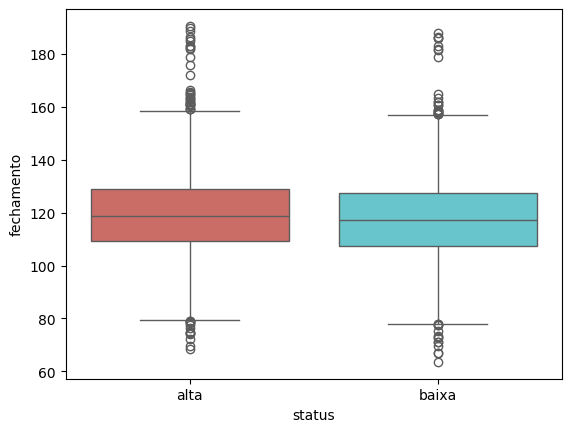

In [284]:
sns.boxplot(x='status', y='fechamento', data=ibovespa, palette='hls')

In [285]:
ibovespa["status_encoded"] = LabelEncoder().fit_transform(ibovespa["status"])

In [286]:
ibovespa.head()

,data,abertura,maxima,minima,fechamento,variacao_percentual,status,status_encoded
0,2026-02-20,188.531,190.727,186.700,190.534,1.06,alta,0
1,2026-02-19,186.020,188.687,185.928,188.534,1.35,alta,0
2,2026-02-18,186.464,187.657,185.001,186.016,-0.24,baixa,1
3,2026-02-13,187.766,187.766,183.662,186.464,-0.69,baixa,1
4,2026-02-12,189.694,189.990,186.959,187.766,-1.02,baixa,1


In [287]:
ibovespa_encoded = ibovespa.copy()
ibovespa_encoded = ibovespa_encoded.drop(columns=['status'])

In [288]:
# correlation_matrix = ibovespa_encoded.corr().round(2)

# fig, ax = plt.subplots(figsize=(8,8))
# sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)

In [289]:
ibovespa_encoded = ibovespa_encoded.rename(columns={'data': 'ds', 'fechamento': 'y'})

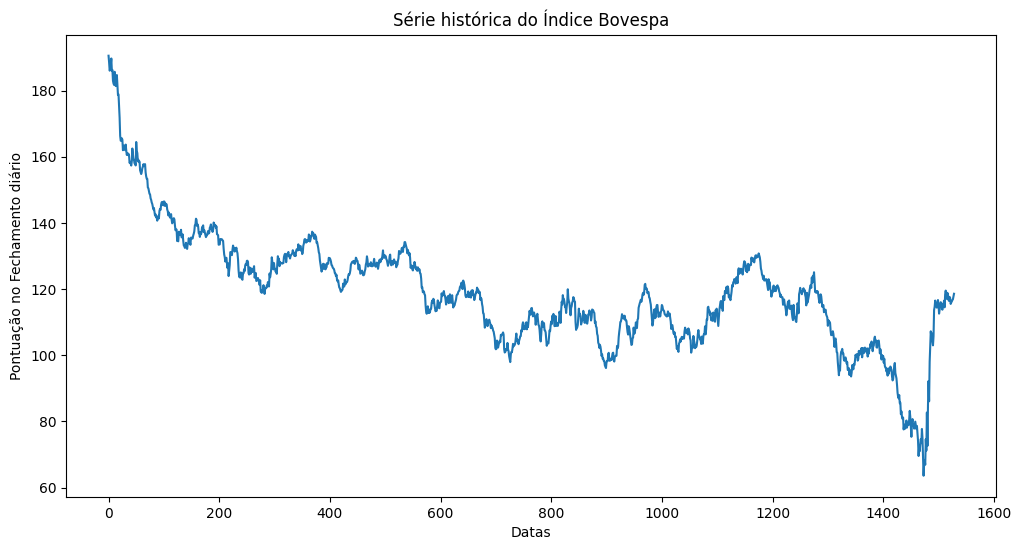

In [290]:
# Análise temporal (série histórica)
plt.figure(figsize=(12, 6))
plt.plot(ibovespa_encoded.index, ibovespa_encoded["y"])
plt.xlabel("Datas")
plt.ylabel("Pontuação no Fechamento diário")
plt.title("Série histórica do Índice Bovespa")
plt.show()

In [291]:
ibovespa_encoded.isnull().sum()

ds                     0
abertura               0
maxima                 0
minima                 0
y                      0
variacao_percentual    0
status_encoded         0
dtype: int64

# Treino e teste - Séries Temporais

In [292]:
ibovespa_encoded_filtrada = ibovespa_encoded.drop(columns=['abertura', 'maxima', 'minima', 'variacao_percentual', 'status_encoded'])
ibovespa_encoded_filtrada["unique_id"] = "ibovespa"

In [293]:
ibovespa_encoded_filtrada.head()

,ds,y,unique_id
0,2026-02-20,190.534,ibovespa
1,2026-02-19,188.534,ibovespa
2,2026-02-18,186.016,ibovespa
3,2026-02-13,186.464,ibovespa
4,2026-02-12,187.766,ibovespa


In [294]:
ibovespa_encoded_filtrada[ibovespa_encoded_filtrada['ds'] == '2020-02-02']

,ds,y,unique_id


In [ ]:
treino = ibovespa_encoded_filtrada[ibovespa_encoded_filtrada['ds'] < '2026-01-07'].dropna()
valid = ibovespa_encoded_filtrada[ibovespa_encoded_filtrada['ds'] >= '2026-01-07'].dropna()
h = valid.index.nunique()

In [296]:
min(treino['ds'])

Timestamp('2020-01-02 00:00:00')

In [297]:
print(h)

31


In [298]:
def func_wmape(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / np.abs((y_true)).sum()

In [299]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoARIMA

In [300]:
model = StatsForecast(models=[Naive(), SeasonalNaive(season_length=7), AutoARIMA(season_length=7)], freq='D', n_jobs=-1)
model.fit(treino)

forecast_df = model.predict(h=h, level=[30])

In [301]:
print(treino.dtypes)
print(valid.dtypes)
print(forecast_df.dtypes)

ds           datetime64[ns]
y                   float64
unique_id            object
dtype: object
ds           datetime64[ns]
y                   float64
unique_id            object
dtype: object
unique_id                      object
ds                     datetime64[ns]
Naive                         float64
Naive-lo-30                   float64
Naive-hi-30                   float64
SeasonalNaive                 float64
SeasonalNaive-lo-30           float64
SeasonalNaive-hi-30           float64
AutoARIMA                     float64
AutoARIMA-lo-30               float64
AutoARIMA-hi-30               float64
dtype: object


In [302]:
forecast_df = forecast_df.merge(valid, on=["unique_id", "ds"], how="left").dropna()

wmape = func_wmape(forecast_df['y'].values, forecast_df['Naive'].values)
print (f"WMAPE Naive: {wmape: .2%}")

wmape1 = func_wmape(forecast_df['y'].values, forecast_df['SeasonalNaive'].values)
print (f"WMAPE SeasonalNaive: {wmape1: .2%}")

wmape2 = func_wmape(forecast_df['y'].values, forecast_df['AutoARIMA'].values)
print (f"WMAPE AutoARIMA: {wmape2: .2%}")

WMAPE Naive:  5.94%
WMAPE SeasonalNaive:  7.10%
WMAPE AutoARIMA:  5.70%


In [303]:
forecast_df.head()

,unique_id,ds,Naive,Naive-lo-30,Naive-hi-30,SeasonalNaive,SeasonalNaive-lo-30,SeasonalNaive-hi-30,AutoARIMA,AutoARIMA-lo-30,AutoARIMA-hi-30,y
0,ibovespa,2026-01-07,163.664,163.063062,164.264938,160.456,158.930825,161.981175,163.786541,163.193595,164.379487,161.975
1,ibovespa,2026-01-08,163.664,162.814145,164.513855,160.897,159.371825,162.422175,163.919561,163.124092,164.715030,162.936
2,ibovespa,2026-01-09,163.664,162.623145,164.704855,160.490,158.964825,162.015175,163.897246,162.921646,164.872845,163.370
5,ibovespa,2026-01-12,163.664,162.192009,165.135991,161.870,160.344825,163.395175,164.072501,162.697293,165.447708,163.150
6,ibovespa,2026-01-13,163.664,162.074068,165.253932,163.664,162.138825,165.189175,164.291814,162.806900,165.776728,161.973


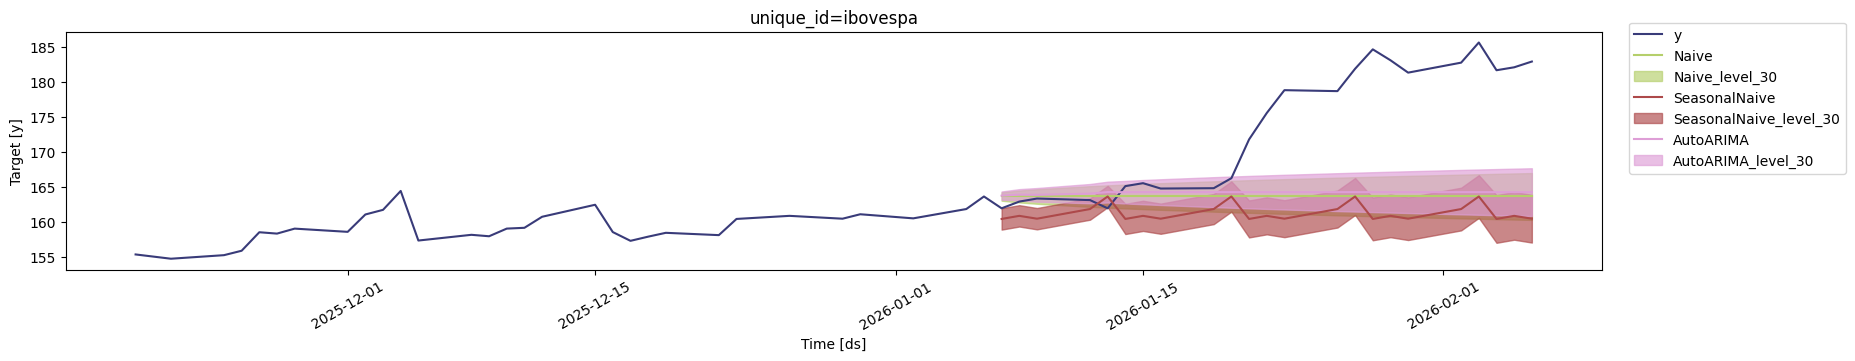

In [304]:
model.plot(treino, forecast_df, level=[30], unique_ids=['ibovespa'], engine = 'matplotlib', max_insample_length=30)